# Probability Theory for Machine Learning

## Why Probability?

Machine learning is fundamentally about **reasoning under uncertainty**. Every prediction a model makes is a probability distribution. Naive Bayes, Gaussian Mixture Models, VAEs, diffusion models all of these are probabilistic. Understanding probability deeply means understanding *why* models work and *how* to reason about their outputs.

---

## Table of Contents
1. Sample Space, Events, Probability Axioms
2. Conditional Probability
3. Bayes' Theorem
4. Independence
5. Random Variables (Discrete & Continuous)
6. PMF, PDF, CDF
7. All Major Probability Distributions
8. Expectation, Variance, Covariance, Correlation
9. Joint, Marginal & Conditional Distributions
10. Central Limit Theorem
11. Law of Large Numbers
12. Monte Carlo Methods

## 1. Sample Space, Events, and Probability Axioms

- **Sample space** $\Omega$: The set of all possible outcomes
- **Event** $A \subseteq \Omega$: A subset of outcomes
- **Probability measure** $P: 2^\Omega \to [0,1]$

### Kolmogorov Axioms
1. **Non-negativity:** $P(A) \geq 0$ for all $A$
2. **Normalization:** $P(\Omega) = 1$
3. **Countable additivity:** If $A_1, A_2, \ldots$ are mutually exclusive:
$$P\left(\bigcup_{i=1}^\infty A_i\right) = \sum_{i=1}^\infty P(A_i)$$

### Derived Properties
- $P(A^c) = 1 - P(A)$
- $P(\emptyset) = 0$
- $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ (inclusion-exclusion)
- $0 \leq P(A) \leq 1$

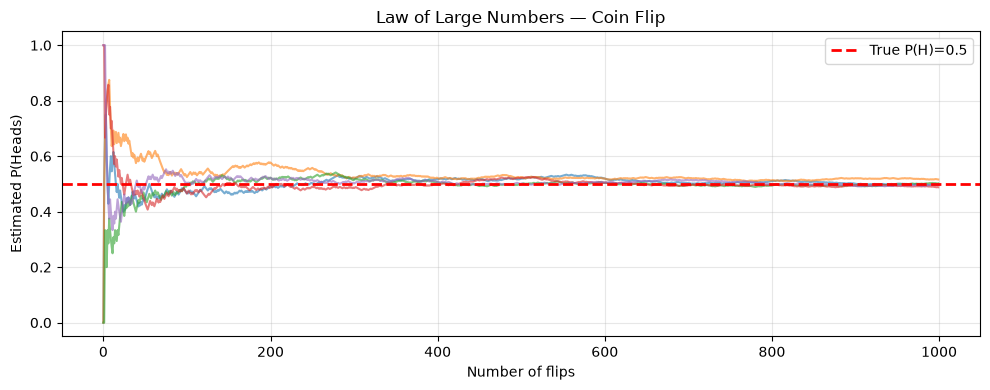

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Simulate probability with coin flip
np.random.seed(42)

def simulate_probability(n_trials, p_head=0.5):
    flips = np.random.binomial(1, p_head, n_trials)
    running_prob = np.cumsum(flips) / np.arange(1, n_trials+1)
    return running_prob

fig, ax = plt.subplots(figsize=(10, 4))
for _ in range(5):
    probs = simulate_probability(1000)
    ax.plot(probs, alpha=0.6)
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='True P(H)=0.5')
ax.set_xlabel('Number of flips')
ax.set_ylabel('Estimated P(Heads)')
ax.set_title('Law of Large Numbers Coin Flip')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Conditional Probability

The probability of event $A$ given that event $B$ has occurred:
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

### Multiplication Rule
$$P(A \cap B) = P(A \mid B) \cdot P(B) = P(B \mid A) \cdot P(A)$$

### Law of Total Probability
If $\{B_1, B_2, \ldots, B_n\}$ is a partition of $\Omega$:
$$P(A) = \sum_{i=1}^n P(A \mid B_i) P(B_i)$$

**Example in ML:** $P(\text{spam}) = P(\text{spam} \mid \text{word=''buy''}) P(\text{word=''buy''}) + P(\text{spam} \mid \text{word}\neq\text{''buy''}) P(\text{word}\neq\text{''buy''})$

## 3. Bayes' Theorem

### Formula
$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Equivalently:
$$\underbrace{P(A \mid B)}_{\text{posterior}} = \frac{\underbrace{P(B \mid A)}_{\text{likelihood}} \cdot \underbrace{P(A)}_{\text{prior}}}{\underbrace{P(B)}_{\text{evidence}}}$$

### General Form
$$P(\theta \mid X) = \frac{P(X \mid \theta) P(\theta)}{P(X)} = \frac{P(X \mid \theta) P(\theta)}{\int P(X \mid \theta) P(\theta)\, d\theta}$$

### Why it matters in ML
- **Naive Bayes classifier**: directly applies Bayes' theorem
- **Bayesian neural networks**: prior over weights, posterior given data
- **Bayesian optimization**: posterior over function values
- **MAP estimation**: maximizes the posterior $P(\theta \mid X)$

In [2]:
import numpy as np

# Bayes' theorem: Medical test example
# Disease prevalence
P_disease = 0.01          # prior: 1% of population has disease
P_pos_given_disease = 0.95   # sensitivity: 95% true positive rate
P_pos_given_no_disease = 0.05  # 5% false positive rate

# Law of total probability
P_positive = (P_pos_given_disease * P_disease + 
              P_pos_given_no_disease * (1 - P_disease))

# Bayes' theorem
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print("=== Medical Test (Bayes' Theorem) ===")
print(f"Prior P(disease) = {P_disease:.2%}")
print(f"Sensitivity P(+|disease) = {P_pos_given_disease:.2%}")
print(f"False positive rate P(+|no disease) = {P_pos_given_no_disease:.2%}")
print(f"P(test positive) = {P_positive:.2%}")
print(f"\nPosterior P(disease | positive test) = {P_disease_given_pos:.2%}")
print("This is surprisingly low! Base rate matters.")

# Bayesian update: what if we test again?
P_updated = P_disease_given_pos  # new prior
P_disease_given_pos2 = (P_pos_given_disease * P_updated) / (
    P_pos_given_disease * P_updated + P_pos_given_no_disease * (1 - P_updated))
print(f"\nAfter 2 positive tests: P(disease) = {P_disease_given_pos2:.2%}")

=== Medical Test (Bayes' Theorem) ===
Prior P(disease) = 1.00%
Sensitivity P(+|disease) = 95.00%
False positive rate P(+|no disease) = 5.00%
P(test positive) = 5.90%

Posterior P(disease | positive test) = 16.10%
This is surprisingly low! Base rate matters.

After 2 positive tests: P(disease) = 78.48%


## 4. Independence

Events $A$ and $B$ are **independent** if:
$$P(A \cap B) = P(A) \cdot P(B)$$

Equivalently: $P(A \mid B) = P(A)$ knowing $B$ gives no information about $A$.

### Conditional Independence
$A$ and $B$ are **conditionally independent given $C$**:
$$P(A \cap B \mid C) = P(A \mid C) \cdot P(B \mid C)$$

**In ML:** Naive Bayes assumes features are conditionally independent given the class label a simplification that works surprisingly well in practice.

## 5-6. Random Variables, PMF, PDF, CDF

A **random variable** $X: \Omega \to \mathbb{R}$ maps outcomes to real numbers.

### Discrete: Probability Mass Function (PMF)
$$P(X = x) = p(x) \geq 0, \quad \sum_{x} p(x) = 1$$

### Continuous: Probability Density Function (PDF)
$$P(a \leq X \leq b) = \int_a^b f_X(x)\, dx, \quad f_X(x) \geq 0, \quad \int_{-\infty}^{\infty} f_X(x)\, dx = 1$$

### Cumulative Distribution Function (CDF)
$$F_X(x) = P(X \leq x) = \begin{cases} \sum_{t \leq x} p(t) & \text{discrete} \\ \int_{-\infty}^x f_X(t)\, dt & \text{continuous} \end{cases}$$

Properties: $F_X(-\infty)=0$, $F_X(\infty)=1$, $F_X$ non-decreasing, right-continuous.

## 7. All Major Probability Distributions

### Discrete Distributions

| Distribution | PMF | Mean | Variance | ML Use |
|-------------|-----|------|----------|--------|
| **Bernoulli($p$)** | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ | Binary classification |
| **Binomial($n,p$)** | $\binom{n}{k}p^k(1-p)^{n-k}$ | $np$ | $np(1-p)$ | Count successes |
| **Multinomial($n,p$)** | $\frac{n!}{k_1!\cdots k_m!}\prod p_i^{k_i}$ | $np_i$ | $np_i(1-p_i)$ | Multi-class |
| **Poisson($\lambda$)** | $\frac{\lambda^k e^{-\lambda}}{k!}$ | $\lambda$ | $\lambda$ | Event counts |
| **Geometric($p$)** | $(1-p)^{k-1}p$ | $1/p$ | $(1-p)/p^2$ | First success |
| **Negative Binomial** | $\binom{k+r-1}{k}p^r(1-p)^k$ | $r(1-p)/p$ | | Overdispersed counts |

### Continuous Distributions

**Normal (Gaussian):** $\mathcal{N}(\mu, \sigma^2)$
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$
Mean: $\mu$, Variance: $\sigma^2$. The most important distribution in ML.

**Uniform:** $\mathcal{U}(a,b)$
$$f(x) = \frac{1}{b-a}, \quad x \in [a,b]$$

**Exponential($\lambda$):**
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0, \quad \text{Mean} = 1/\lambda$$

**Beta($\alpha, \beta$):** (for probabilities $x \in [0,1]$)
$$f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}, \quad B(\alpha,\beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$
Used as conjugate prior for Bernoulli/Binomial.

**Gamma($\alpha, \beta$):**
$$f(x) = \frac{\beta^\alpha x^{\alpha-1} e^{-\beta x}}{\Gamma(\alpha)}, \quad x > 0$$
Conjugate prior for Poisson rate.

**Dirichlet($\boldsymbol{\alpha}$):** (multivariate Beta)
$$f(\mathbf{x}) = \frac{1}{B(\boldsymbol{\alpha})} \prod_{i=1}^k x_i^{\alpha_i - 1}$$
Used in topic modeling (LDA) as prior over categorical distributions.

**Chi-squared($k$):** $\chi^2 = \sum_{i=1}^k Z_i^2$ where $Z_i \sim \mathcal{N}(0,1)$. Used in hypothesis testing.

**Student's t($\nu$):** Heavy-tailed, used when population variance is unknown.
$$f(t) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

**Multivariate Normal:** $\mathcal{N}(\boldsymbol{\mu}, \Sigma)$
$$f(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x}-\boldsymbol{\mu})\right)$$
Foundation of Gaussian Mixture Models, Gaussian Processes, VAE latent space.

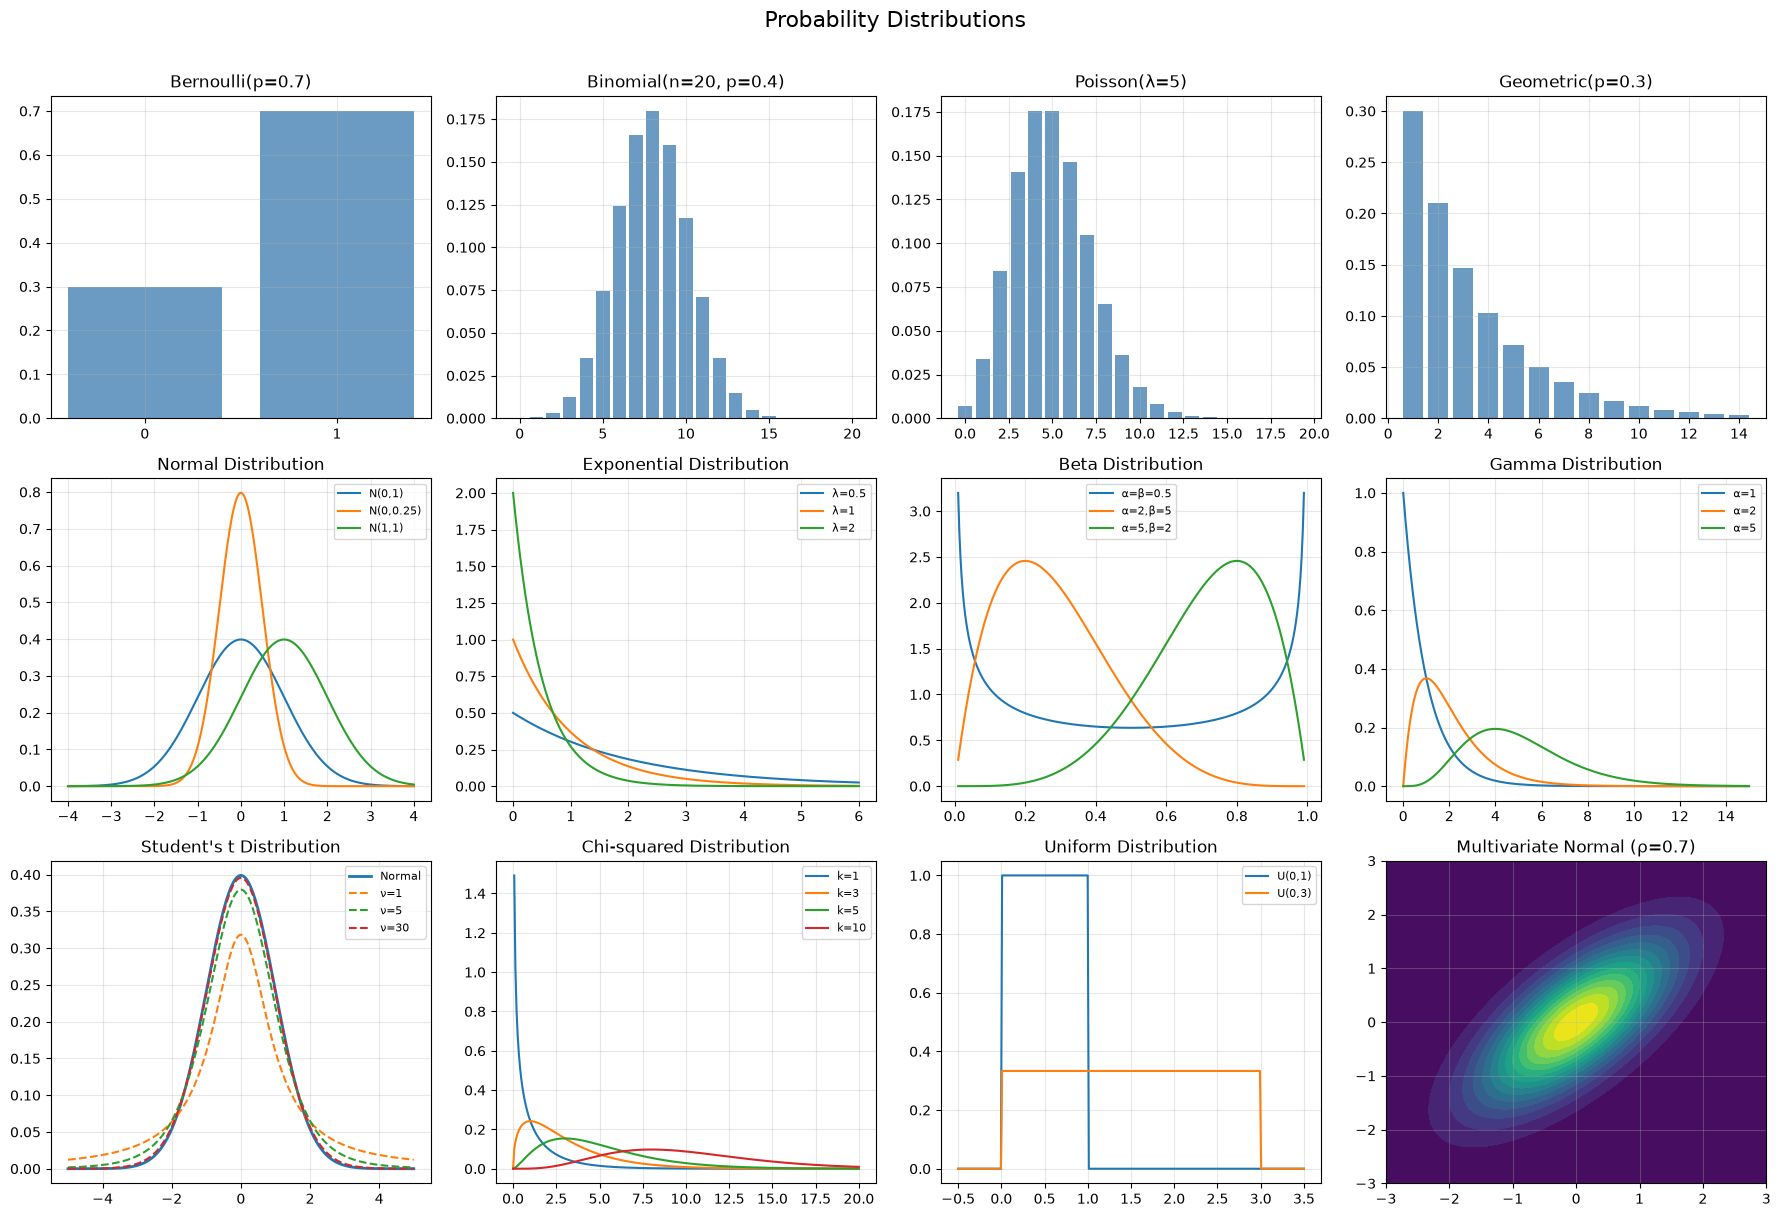

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

# Discrete distributions
# Bernoulli
p = 0.7
x = [0, 1]
axes[0].bar(x, [1-p, p], color='steelblue', alpha=0.8)
axes[0].set_title(f'Bernoulli(p={p})')
axes[0].set_xticks([0,1])

# Binomial
n, p = 20, 0.4
x = np.arange(0, n+1)
axes[1].bar(x, stats.binom.pmf(x, n, p), color='steelblue', alpha=0.8)
axes[1].set_title(f'Binomial(n={n}, p={p})')

# Poisson
lam = 5
x = np.arange(0, 20)
axes[2].bar(x, stats.poisson.pmf(x, lam), color='steelblue', alpha=0.8)
axes[2].set_title(f'Poisson(λ={lam})')

# Geometric
p = 0.3
x = np.arange(1, 15)
axes[3].bar(x, stats.geom.pmf(x, p), color='steelblue', alpha=0.8)
axes[3].set_title(f'Geometric(p={p})')

# Continuous distributions
x_cont = np.linspace(-4, 4, 300)

# Normal
for mu, sigma, label in [(0, 1, 'N(0,1)'), (0, 0.5, 'N(0,0.25)'), (1, 1, 'N(1,1)')]:
    axes[4].plot(x_cont, stats.norm.pdf(x_cont, mu, sigma), label=label)
axes[4].set_title('Normal Distribution')
axes[4].legend(fontsize=8)

# Exponential
x_exp = np.linspace(0, 6, 300)
for lam, label in [(0.5, 'λ=0.5'), (1, 'λ=1'), (2, 'λ=2')]:
    axes[5].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam), label=label)
axes[5].set_title('Exponential Distribution')
axes[5].legend(fontsize=8)

# Beta
x_beta = np.linspace(0.01, 0.99, 300)
for a, b, label in [(0.5, 0.5, 'α=β=0.5'), (2, 5, 'α=2,β=5'), (5, 2, 'α=5,β=2')]:
    axes[6].plot(x_beta, stats.beta.pdf(x_beta, a, b), label=label)
axes[6].set_title('Beta Distribution')
axes[6].legend(fontsize=8)

# Gamma
x_gamma = np.linspace(0, 15, 300)
for a, label in [(1, 'α=1'), (2, 'α=2'), (5, 'α=5')]:
    axes[7].plot(x_gamma, stats.gamma.pdf(x_gamma, a), label=label)
axes[7].set_title('Gamma Distribution')
axes[7].legend(fontsize=8)

# Student's t
x_t = np.linspace(-5, 5, 300)
axes[8].plot(x_t, stats.norm.pdf(x_t), label='Normal', linewidth=2)
for df, label in [(1, 'ν=1'), (5, 'ν=5'), (30, 'ν=30')]:
    axes[8].plot(x_t, stats.t.pdf(x_t, df), '--', label=label)
axes[8].set_title("Student's t Distribution")
axes[8].legend(fontsize=8)

# Chi-squared
x_chi = np.linspace(0, 20, 300)
for k, label in [(1, 'k=1'), (3, 'k=3'), (5, 'k=5'), (10, 'k=10')]:
    axes[9].plot(x_chi, stats.chi2.pdf(x_chi, k), label=label)
axes[9].set_title('Chi-squared Distribution')
axes[9].legend(fontsize=8)

# Uniform
x_unif = np.linspace(-0.5, 3.5, 300)
for a, b, label in [(0, 1, 'U(0,1)'), (0, 3, 'U(0,3)')]:
    axes[10].plot(x_unif, stats.uniform.pdf(x_unif, a, b-a), label=label)
axes[10].set_title('Uniform Distribution')
axes[10].legend(fontsize=8)

# Multivariate Normal (2D)
mean = [0, 0]
cov = [[1, 0.7], [0.7, 1]]
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))
rv = stats.multivariate_normal(mean, cov)
axes[11].contourf(X1, X2, rv.pdf(pos), levels=20, cmap='viridis')
axes[11].set_title('Multivariate Normal (ρ=0.7)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Probability Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 8. Expectation, Variance, Covariance, Correlation

### Expectation (Mean)
$$\mathbb{E}[X] = \begin{cases} \sum_x x \cdot p(x) & \text{discrete} \\ \int_{-\infty}^\infty x \cdot f(x)\, dx & \text{continuous} \end{cases}$$

**Linearity:** $\mathbb{E}[aX + bY] = a\mathbb{E}[X] + b\mathbb{E}[Y]$

### Variance
$$\text{Var}(X) = \mathbb{E}[(X - \mu)^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$
Standard deviation: $\sigma = \sqrt{\text{Var}(X)}$

### Covariance
$$\text{Cov}(X, Y) = \mathbb{E}[(X - \mu_X)(Y - \mu_Y)] = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]$$

If $X, Y$ independent: $\text{Cov}(X,Y) = 0$

### Correlation (Pearson)
$$\rho(X, Y) = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

### Covariance Matrix
For vector $\mathbf{X} = [X_1, \ldots, X_d]^T$:
$$\Sigma = \text{Cov}(\mathbf{X}) = \mathbb{E}[(\mathbf{X}-\boldsymbol{\mu})(\mathbf{X}-\boldsymbol{\mu})^T]$$
$$(\Sigma)_{ij} = \text{Cov}(X_i, X_j)$$
Always symmetric positive semi-definite (PSD).

In [4]:
import numpy as np

# Expectation and Variance
np.random.seed(0)
X = np.random.normal(5, 2, 10000)
Y = 2*X + np.random.normal(0, 1, 10000)

print(f"E[X] = {np.mean(X):.4f} (true: 5.0)")
print(f"Var(X) = {np.var(X):.4f} (true: 4.0)")
print(f"Std(X) = {np.std(X):.4f} (true: 2.0)")

# Covariance and Correlation
cov_XY = np.cov(X, Y, ddof=1)
print(f"\nCovariance matrix:\n{cov_XY.round(3)}")

corr = np.corrcoef(X, Y)
print(f"Correlation matrix:\n{corr.round(3)}")

# E[aX + bY]
a, b = 3, -1
Z = a*X + b*Y
print(f"\nE[3X - Y] = {np.mean(Z):.4f}")
print(f"3E[X] - E[Y] = {3*np.mean(X) - np.mean(Y):.4f} (linearity check)")

E[X] = 4.9631 (true: 5.0)
Var(X) = 3.9011 (true: 4.0)
Std(X) = 1.9751 (true: 2.0)

Covariance matrix:
[[ 3.901  7.788]
 [ 7.788 16.531]]
Correlation matrix:
[[1.   0.97]
 [0.97 1.  ]]

E[3X - Y] = 4.9521
3E[X] - E[Y] = 4.9521 (linearity check)


## 9. Joint, Marginal & Conditional Distributions

### Joint Distribution
$$p(x, y) = P(X=x, Y=y) \quad \text{(discrete)}$$
$$f(x, y) \quad \text{such that} \int\int f(x,y)\, dx\, dy = 1 \quad \text{(continuous)}$$

### Marginal Distribution
$$p_X(x) = \sum_y p(x, y) \quad \text{(discrete)}$$
$$f_X(x) = \int_{-\infty}^\infty f(x, y)\, dy \quad \text{(continuous)}$$

### Conditional Distribution
$$p(x \mid y) = \frac{p(x, y)}{p_Y(y)}, \quad f(x \mid y) = \frac{f(x,y)}{f_Y(y)}$$

**In VAEs:** The encoder learns $q(z \mid x)$ (approximate posterior), decoder learns $p(x \mid z)$ (likelihood).

## 10. Central Limit Theorem (CLT)

### Statement
Let $X_1, X_2, \ldots, X_n$ be i.i.d. random variables with mean $\mu$ and variance $\sigma^2 < \infty$. Then:
$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{as } n \to \infty$$

Equivalently: $\bar{X}_n \approx \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$ for large $n$.

**Why it matters:** This is why the Normal distribution appears everywhere! The sum of many independent random variables (regardless of their distribution) converges to a Gaussian. This justifies:
- Gaussian noise assumptions in regression
- Stochastic gradient descent behaving like Langevin dynamics
- Mini-batch gradient estimates being approximately normal

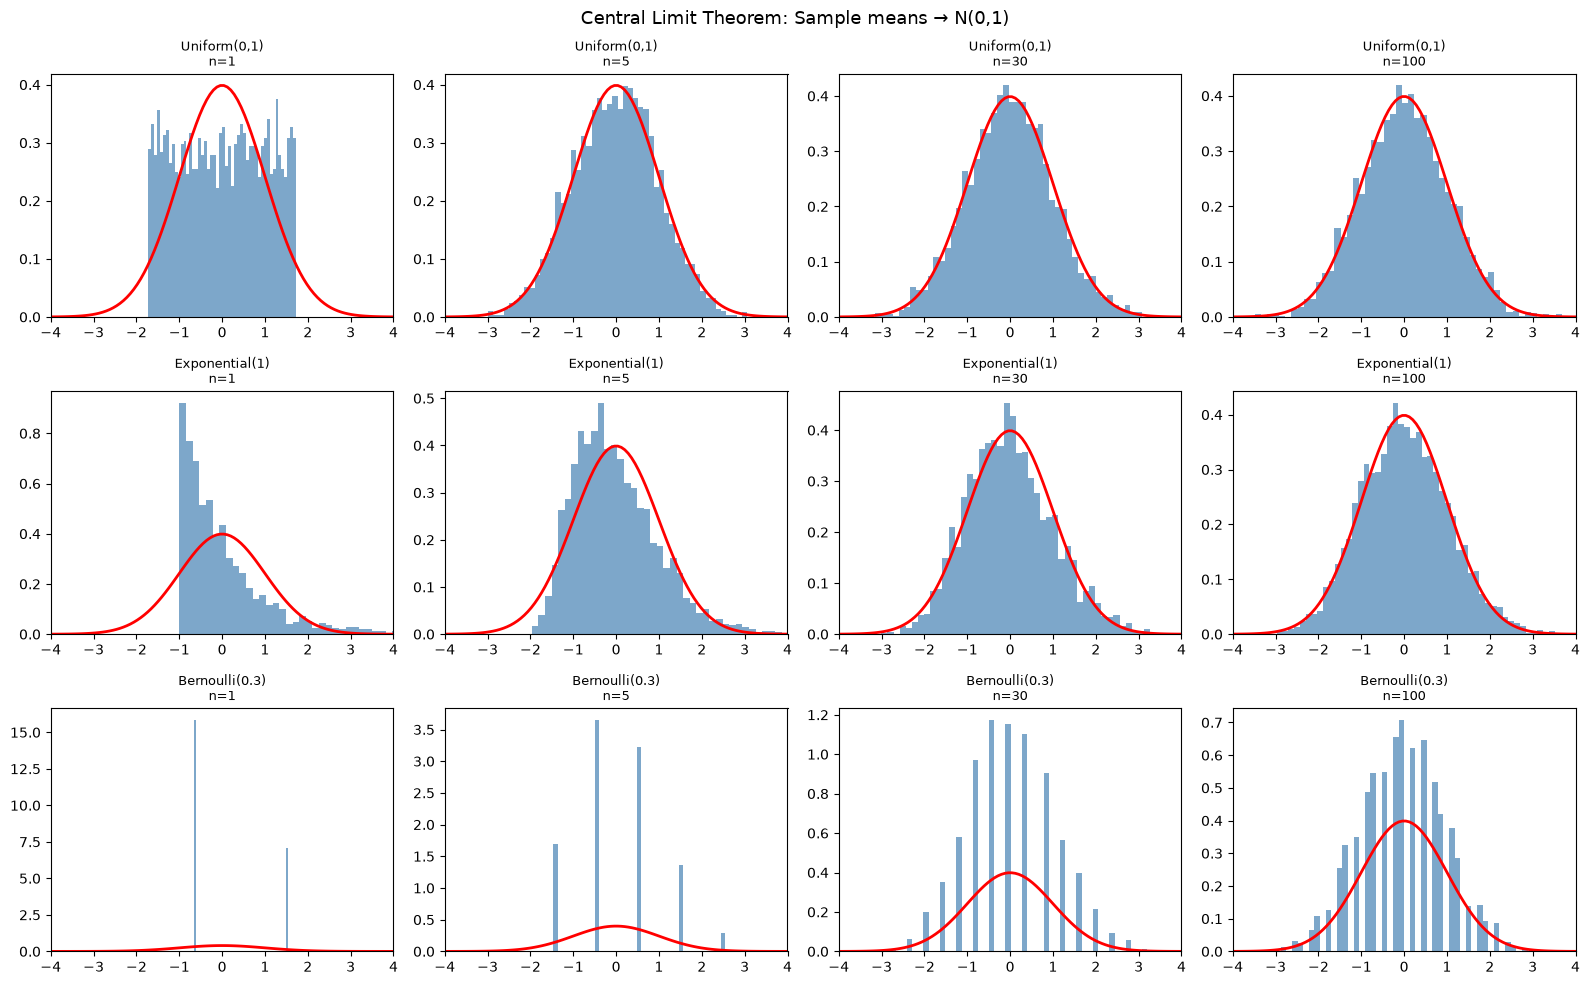

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# CLT demonstration
np.random.seed(42)

distributions = [
    ('Uniform(0,1)', lambda n: np.random.uniform(0, 1, n), 0.5, 1/12),
    ('Exponential(1)', lambda n: np.random.exponential(1, n), 1, 1),
    ('Bernoulli(0.3)', lambda n: np.random.binomial(1, 0.3, n), 0.3, 0.3*0.7),
]

ns = [1, 5, 30, 100]
n_simulations = 3000

fig, axes = plt.subplots(len(distributions), len(ns), figsize=(16, 10))

for i, (dist_name, dist_fn, mu, var) in enumerate(distributions):
    for j, n in enumerate(ns):
        sample_means = [np.mean(dist_fn(n)) for _ in range(n_simulations)]
        sample_means = np.array(sample_means)
        
        # Standardize
        Z = (sample_means - mu) / np.sqrt(var / n)
        
        axes[i, j].hist(Z, bins=50, density=True, alpha=0.7, color='steelblue')
        
        # Overlay N(0,1)
        z = np.linspace(-4, 4, 100)
        axes[i, j].plot(z, stats.norm.pdf(z), 'r-', linewidth=2)
        axes[i, j].set_title(f'{dist_name}\nn={n}', fontsize=9)
        axes[i, j].set_xlim(-4, 4)

plt.suptitle('Central Limit Theorem: Sample means → N(0,1)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Law of Large Numbers

### Weak Law of Large Numbers
For i.i.d. $X_1, \ldots, X_n$ with mean $\mu$:
$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu \quad \text{as } n \to \infty$$

### Strong Law of Large Numbers
$$P\left(\lim_{n\to\infty} \bar{X}_n = \mu\right) = 1$$

**In ML:** Justifies using mini-batch gradients as estimates of the full gradient. As batch size increases, the gradient estimate becomes more accurate. Monte Carlo sampling converges to the true expectation.

## 12. Monte Carlo Methods

**Idea:** Approximate expectations and integrals using random sampling.

$$\mathbb{E}_{x \sim p}[f(x)] = \int f(x) p(x)\, dx \approx \frac{1}{N} \sum_{i=1}^N f(x_i), \quad x_i \sim p$$

### Importance Sampling
When we can't sample from $p$, sample from proposal $q$:
$$\mathbb{E}_p[f(x)] = \mathbb{E}_q\left[f(x) \frac{p(x)}{q(x)}\right] \approx \frac{1}{N} \sum_{i=1}^N f(x_i) \frac{p(x_i)}{q(x_i)}, \quad x_i \sim q$$

**In ML:** REINFORCE algorithm, policy gradients in RL, variational inference in VAEs all use Monte Carlo estimates.

In [6]:
import numpy as np

# Monte Carlo estimation of π
np.random.seed(42)

def estimate_pi(n):
    x = np.random.uniform(-1, 1, n)
    y = np.random.uniform(-1, 1, n)
    inside = (x**2 + y**2) <= 1
    return 4 * inside.mean()

for n in [100, 1000, 10000, 100000, 1000000]:
    pi_est = estimate_pi(n)
    print(f"n={n:>8,}: π ≈ {pi_est:.6f} (error: {abs(pi_est - np.pi):.6f})")

print(f"True π = {np.pi:.6f}")

# Monte Carlo integration
# Estimate E[X^2] for X ~ N(0,1) (should be 1)
N = 100000
samples = np.random.normal(0, 1, N)
estimate = np.mean(samples**2)
print(f"\nMC estimate of E[X²] for N(0,1): {estimate:.4f} (true: 1.0)")

# Estimate normalization constant
# ∫₋∞^∞ exp(-x²/2) dx = √(2π)
# Use importance sampling with N(0,1) proposal
samples = np.random.normal(0, 1, N)
f = np.exp(-samples**2 / 2)
q = np.exp(-samples**2 / 2) / np.sqrt(2 * np.pi)
weights = f / q
estimate = np.mean(weights) * np.sqrt(2 * np.pi)
print(f"MC estimate of ∫ exp(-x²/2) dx: {np.mean(f/q):.4f} × √(2π) ≈ {estimate:.4f}")
print(f"True value: {np.sqrt(2*np.pi):.4f}")

n=     100: π ≈ 3.280000 (error: 0.138407)
n=   1,000: π ≈ 3.080000 (error: 0.061593)
n=  10,000: π ≈ 3.142400 (error: 0.000807)
n= 100,000: π ≈ 3.141840 (error: 0.000247)
n=1,000,000: π ≈ 3.140220 (error: 0.001373)
True π = 3.141593

MC estimate of E[X²] for N(0,1): 1.0050 (true: 1.0)
MC estimate of ∫ exp(-x²/2) dx: 2.5066 × √(2π) ≈ 6.2832
True value: 2.5066


## Additional Learning Resources

### Video Courses
- **StatQuest Probability & Statistics**: https://www.youtube.com/playlist?list=PLblh5JKOoLUIcdlgu78MnlATeyx4cEVeR
- **Harvard Statistics 110 Probability**: https://projects.iq.harvard.edu/stat110/home
- **MIT 6.041 Probabilistic Systems Analysis**: https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/
- **3Blue1Brown Bayes Theorem**: https://www.youtube.com/watch?v=HZGCoVF3YvM

### Books
- **Probability Theory: The Logic of Science Jaynes** (free): https://bayes.wustl.edu/etj/prob/book.pdf
- **Think Stats (Free book)**: https://greenteapress.com/thinkstats2/
- **Introduction to Probability Blitzstein & Hwang (Free PDF)**: https://projects.iq.harvard.edu/stat110/strategic-practice-problems-0
- **Deep Learning Book Ch 3 (Probability)**: https://www.deeplearningbook.org/contents/prob.html
- **MML Book Ch 6 (Probability)**: https://mml-book.github.io/book/mml-book.pdf

### Papers
- **Latent Dirichlet Allocation (LDA uses Dirichlet)**: https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf
- **VAE Auto-Encoding Variational Bayes**: https://arxiv.org/abs/1312.6114
- **Normalizing Flows (change of variables)**: https://arxiv.org/abs/1908.09257

### Interactive
- **Seeing Theory (Visual Probability)**: https://seeing-theory.brown.edu/
- **Khan Academy Statistics & Probability**: https://www.khanacademy.org/math/statistics-probability